In [ ]:
import kagglehub

In [ ]:
kagglehub.dataset_download("undefinenull/million-song-dataset-spotify-lastfm")

Using Colab cache for faster access to the 'million-song-dataset-spotify-lastfm' dataset.


'/kaggle/input/million-song-dataset-spotify-lastfm'

In [ ]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
data_path = Path("/root/.cache/kagglehub/datasets/undefinenull/million-song-dataset-spotify-lastfm/versions/1")

In [ ]:
song_data_path = data_path / 'Music Info.csv'
user_data_path = data_path / 'User Listening History.csv'

In [ ]:
df_songs = pd.read_csv(song_data_path)

In [ ]:
df_songs.head()

,track_id,name,artist,spotify_preview_url,spotify_id,tags,genre,year,duration_ms,danceability,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,TRIOREW128F424EAF0,Mr. Brightside,The Killers,https://p.scdn.co/mp3-preview/4d26180e6961fd46...,09ZQ5TmUG8TSL56n0knqrj,"rock, alternative, indie, alternative_rock, in...",NaN,2004,222200,0.355,...,1,-4.360,1,0.0746,0.001190,0.000000,0.0971,0.240,148.114,4
1,TRRIVDJ128F429B0E8,Wonderwall,Oasis,https://p.scdn.co/mp3-preview/d012e536916c927b...,06UfBBDISthj1ZJAtX4xjj,"rock, alternative, indie, pop, alternative_roc...",NaN,2006,258613,0.409,...,2,-4.373,1,0.0336,0.000807,0.000000,0.2070,0.651,174.426,4
2,TROUVHL128F426C441,Come as You Are,Nirvana,https://p.scdn.co/mp3-preview/a1c11bb1cb231031...,0keNu0t0tqsWtExGM3nT1D,"rock, alternative, alternative_rock, 90s, grunge",RnB,1991,218920,0.508,...,4,-5.783,0,0.0400,0.000175,0.000459,0.0878,0.543,120.012,4
3,TRUEIND128F93038C4,Take Me Out,Franz Ferdinand,https://p.scdn.co/mp3-preview/399c401370438be4...,0ancVQ9wEcHVd0RrGICTE4,"rock, alternative, indie, alternative_rock, in...",NaN,2004,237026,0.279,...,9,-8.851,1,0.0371,0.000389,0.000655,0.1330,0.490,104.560,4
4,TRLNZBD128F935E4D8,Creep,Radiohead,https://p.scdn.co/mp3-preview/e7eb60e9466bc3a2...,01QoK9DA7VTeTSE3MNzp4I,"rock, alternative, indie, alternative_rock, in...",RnB,2008,238640,0.515,...,7,-9.935,1,0.0369,0.010200,0.000141,0.1290,0.104,91.841,4


In [ ]:
df_songs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50683 entries, 0 to 50682
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   track_id             50683 non-null  object 
 1   name                 50683 non-null  object 
 2   artist               50683 non-null  object 
 3   spotify_preview_url  50683 non-null  object 
 4   spotify_id           50683 non-null  object 
 5   tags                 49556 non-null  object 
 6   genre                22348 non-null  object 
 7   year                 50683 non-null  int64  
 8   duration_ms          50683 non-null  int64  
 9   danceability         50683 non-null  float64
 10  energy               50683 non-null  float64
 11  key                  50683 non-null  int64  
 12  loudness             50683 non-null  float64
 13  mode                 50683 non-null  int64  
 14  speechiness          50683 non-null  float64
 15  acousticness         50683 non-null 

In [ ]:
df_songs.isna().sum()

,0
track_id,0
name,0
artist,0
spotify_preview_url,0
spotify_id,0
tags,1127
genre,28335
year,0
duration_ms,0
danceability,0


# What is missing ?
1 -> genre has only 22348 values out of 50683 entries
which is more that half

2 -> 1127 tags value misses

In [ ]:
# we are not using "spotify_preview_url" , so we remove it
df_songs.drop(columns =["spotify_preview_url"],inplace = True)

In [ ]:
df_songs

,track_id,name,artist,spotify_id,tags,genre,year,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,TRIOREW128F424EAF0,Mr. Brightside,The Killers,09ZQ5TmUG8TSL56n0knqrj,"rock, alternative, indie, alternative_rock, in...",NaN,2004,222200,0.355,0.918,1,-4.360,1,0.0746,0.001190,0.000000,0.0971,0.240,148.114,4
1,TRRIVDJ128F429B0E8,Wonderwall,Oasis,06UfBBDISthj1ZJAtX4xjj,"rock, alternative, indie, pop, alternative_roc...",NaN,2006,258613,0.409,0.892,2,-4.373,1,0.0336,0.000807,0.000000,0.2070,0.651,174.426,4
2,TROUVHL128F426C441,Come as You Are,Nirvana,0keNu0t0tqsWtExGM3nT1D,"rock, alternative, alternative_rock, 90s, grunge",RnB,1991,218920,0.508,0.826,4,-5.783,0,0.0400,0.000175,0.000459,0.0878,0.543,120.012,4
3,TRUEIND128F93038C4,Take Me Out,Franz Ferdinand,0ancVQ9wEcHVd0RrGICTE4,"rock, alternative, indie, alternative_rock, in...",NaN,2004,237026,0.279,0.664,9,-8.851,1,0.0371,0.000389,0.000655,0.1330,0.490,104.560,4
4,TRLNZBD128F935E4D8,Creep,Radiohead,01QoK9DA7VTeTSE3MNzp4I,"rock, alternative, indie, alternative_rock, in...",RnB,2008,238640,0.515,0.430,7,-9.935,1,0.0369,0.010200,0.000141,0.1290,0.104,91.841,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50678,TRQYCFV128F9322F50,Ryusei Rocket,アンティック-珈琲店-,0tt1RdeJX1RyuU4hMEZ19T,NaN,NaN,2008,273440,0.438,0.933,6,-3.062,0,0.1650,0.003120,0.000000,0.1300,0.421,166.956,4
50679,TRHQCSH128F42724B7,Colors Of The Wind,ACIDMAN,3wkdfXGf5JYErW4b35zP2h,"rock, alternative_rock, japanese, cover",NaN,2004,275133,0.351,0.693,0,-6.811,1,0.1200,0.000940,0.000049,0.1920,0.450,200.350,4
50680,TRZRODK128F92D68D7,The Revelation,coldrain,1gXMORZRGA40PE9rDE9cja,"metal, metalcore, post_hardcore",NaN,2014,254826,0.434,0.975,10,-3.092,0,0.2680,0.000108,0.001410,0.1630,0.282,158.025,4
50681,TRGLMEM128F9322F63,Koi no Dependence,アンティック-珈琲店-,1dxMDGvIYHFYgRvmw1uMHG,NaN,NaN,2008,243293,0.513,0.902,4,-3.914,0,0.0530,0.000715,0.001350,0.0571,0.618,109.923,4


In [ ]:
df_songs.shape

(50683, 20)

In [ ]:
# df_songs['name'].str.lower().duplicated().sum()

(
    df_songs
    .assign(name=df_songs['name'].str.lower())
    .duplicated(subset='name')
    .sum()
)

np.int64(815)

# duplicates = 815
it is not reliable as same song can be sing my multiple artists or different song also have same tittle or name

In [ ]:
df_songs.columns

Index(['track_id', 'name', 'artist', 'spotify_id', 'tags', 'genre', 'year',
       'duration_ms', 'danceability', 'energy', 'key', 'loudness', 'mode',
       'speechiness', 'acousticness', 'instrumentalness', 'liveness',
       'valence', 'tempo', 'time_signature'],
      dtype='object')

In [ ]:
df_songs['spotify_id'].duplicated().sum()

np.int64(9)

In [ ]:
df_songs.duplicated(subset=["spotify_id","year","duration_ms"]).sum()

np.int64(9)

# actual duplicates
i check table multiple times read manually and check and i find only 9 are duplicates so me remove them as if we make recommendation system it , and select top 5 similar song if one duplicate similar than we only get duplicates songs not some good stuff

In [ ]:
df_songs.drop_duplicates(subset=["spotify_id","year","duration_ms"],inplace=True)

In [ ]:
df_songs.duplicated(subset=["spotify_id","year","duration_ms"]).sum()

np.int64(0)

In [ ]:
df_songs['spotify_id'].duplicated().sum()

np.int64(0)

In [ ]:
# categorical data
categorical_features = df_songs.select_dtypes(include='object').columns

In [ ]:
categorical_features

Index(['track_id', 'name', 'artist', 'spotify_id', 'tags', 'genre'], dtype='object')

In [ ]:
for col in categorical_features:
    print(col)
    print("Unique:", df_songs[col].nunique())
    print("-"*30)

track_id
Unique: 50674
------------------------------
name
Unique: 50674
------------------------------
artist
Unique: 8317
------------------------------
spotify_id
Unique: 50674
------------------------------
tags
Unique: 20054
------------------------------
genre
Unique: 15
------------------------------


In [ ]:
df_songs['artist'].value_counts()

,count
artist,
The Rolling Stones,132
Radiohead,110
Autechre,105
Tom Waits,100
Bob Dylan,98
...,...
Blind Witness,1
Sea Of Treachery,1
King Conquer,1


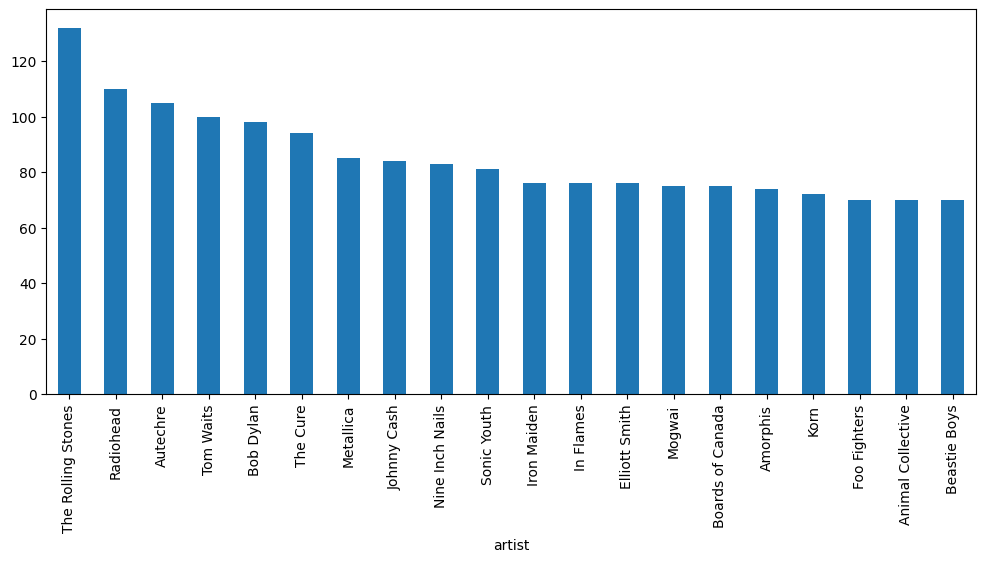

In [ ]:
df_songs['artist'].value_counts().head(20).plot(
    kind='bar',
    figsize=(12,5)
)

plt.show()

In [ ]:
df_songs['genre'].value_counts()

,count
genre,
Rock,9965
Electronic,3710
Metal,2516
Pop,1145
Rap,820
Jazz,793
RnB,696
Reggae,691
Country,607


# find song tittle which are not in english

In [ ]:
!pip install langdetect

In [ ]:
from langdetect import detect

In [ ]:
def detect_language(text):
    try:
        return detect(text)
    except:
        return "unknown"


In [ ]:
sample = df_songs.sample(1000)

sample['language'] = sample['artist'].apply(detect_language)

sample['language'].value_counts()

,count
language,
en,373
de,116
nl,45
tl,35
cy,34
id,34
ro,32
fr,29
fi,27


In [ ]:
df_songs['tags'][0]

'rock, alternative, indie, alternative_rock, indie_rock, 00s'

In [ ]:
# unique tags
(
    df_songs
    .loc[:,"tags"]
    .dropna()
    .str.split(",")
    .explode()
    .str.strip()
    .nunique()
)


100

# integer columns

In [ ]:
integer_columns = df_songs.select_dtypes(include="int").columns

In [ ]:
integer_columns

Index(['year', 'duration_ms', 'key', 'mode', 'time_signature'], dtype='object')

In [ ]:
df_songs[integer_columns]

,year,duration_ms,key,mode,time_signature
0,2004,222200,1,1,4
1,2006,258613,2,1,4
2,1991,218920,4,0,4
3,2004,237026,9,1,4
4,2008,238640,7,1,4
...,...,...,...,...,...
50678,2008,273440,6,0,4
50679,2004,275133,0,1,4
50680,2014,254826,10,0,4
50681,2008,243293,4,0,4


In [ ]:
(
    df_songs
    .loc[:,integer_columns]
    .drop(columns = ["duration_ms"])
    .assign(**{
        col : df_songs[col].astype("object")
        for col in integer_columns.drop("duration_ms")
    })
    .describe()
)

,year,key,mode,time_signature
count,50674,50674,50674,50674
unique,75,12,2,5
top,2007,9,1,4
freq,4221,5907,31979,44981


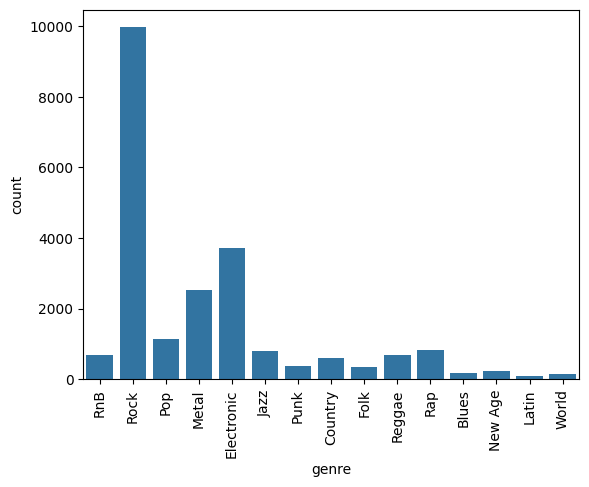

In [ ]:
sns.countplot(df_songs,x="genre")
plt.xticks(rotation=90)
plt.show()

# Some important terms
1 - key
when value is smaller represents key like c and d
when value is larger represents key like A# and B

2 - Modularity

0 - minor(sadness or tension)
1 - major(happiness or resoulution)


3 - Time Signature
smaller value- indicates fewer beats per measure
larger value - indicates more beats per measure

In [ ]:
(
    df_songs
    .loc[:,["duration_ms"]]
    .assign(duration_minutes = df_songs["duration_ms"].div(1000).div(60))
    .drop(columns="duration_ms")
    .describe()
)

,duration_minutes
count,50674.000000
mean,4.185893
std,1.793154
min,0.023983
25%,3.212217
50%,3.915550
75%,4.803046
max,63.606217


In [ ]:
def numerical_analysis(df, column):

    # statistics
    stats = (
        df[column]
        .agg([
            "count",
            "mean",
            "median",
            "std",
            "var",
            "min",
            "max",
            "skew",
            "kurt"
        ])
    )

    stats["missing_values"] = df[column].isna().sum()
    stats["unique_values"] = df[column].nunique()

    print(stats)

    # histogram
    plt.figure(figsize=(8,4))
    plt.hist(df[column].dropna(), bins=30)
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.show()


    # boxplot
    plt.figure(figsize=(8,3))
    plt.boxplot(
        df[column].dropna(),
        vert=False
    )
    plt.title(f"Boxplot of {column}")
    plt.xlabel(column)
    plt.show()

count             5.067400e+04
mean              2.511536e+05
median            2.349330e+05
std               1.075892e+05
var               1.157544e+10
min               1.439000e+03
max               3.816373e+06
skew              3.908298e+00
kurt              5.510145e+01
missing_values    0.000000e+00
unique_values     2.420200e+04
Name: duration_ms, dtype: float64


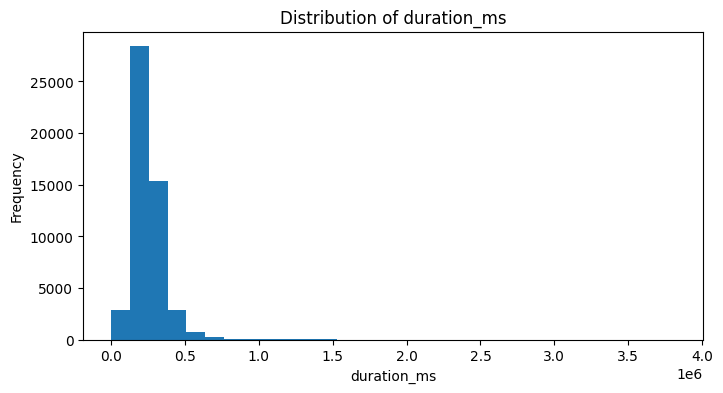

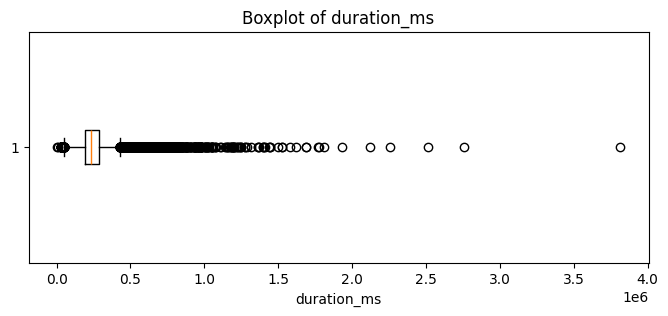

In [ ]:
numerical_analysis(df_songs, "duration_ms")

count             50674.000000
mean                  0.631073
median                1.000000
std                   0.482519
var                   0.232824
min                   0.000000
max                   1.000000
skew                 -0.543309
kurt                 -1.704883
missing_values        0.000000
unique_values         2.000000
Name: mode, dtype: float64


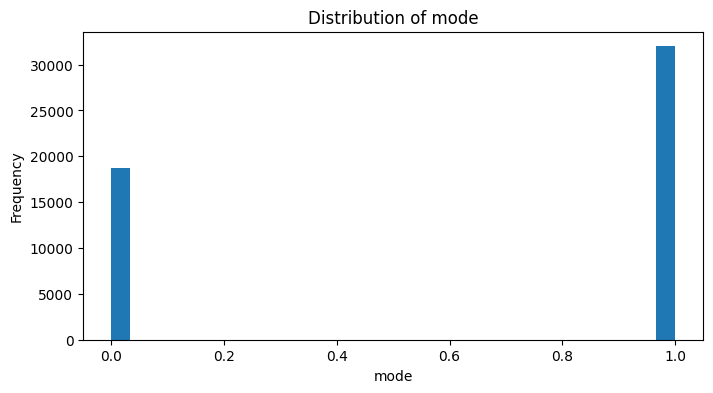

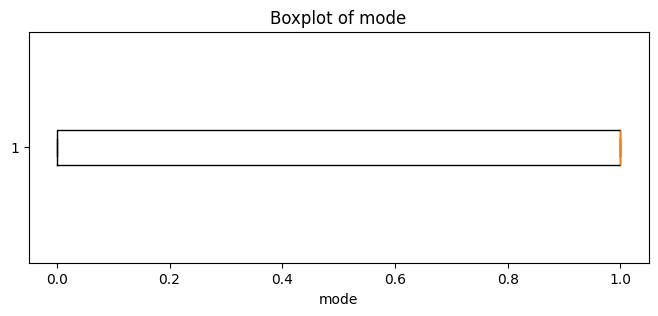

In [ ]:
numerical_analysis(df_songs, "mode")

count             50674.000000
mean                  3.898153
median                4.000000
std                   0.419686
var                   0.176137
min                   0.000000
max                   5.000000
skew                 -3.685393
kurt                 21.262420
missing_values        0.000000
unique_values         5.000000
Name: time_signature, dtype: float64


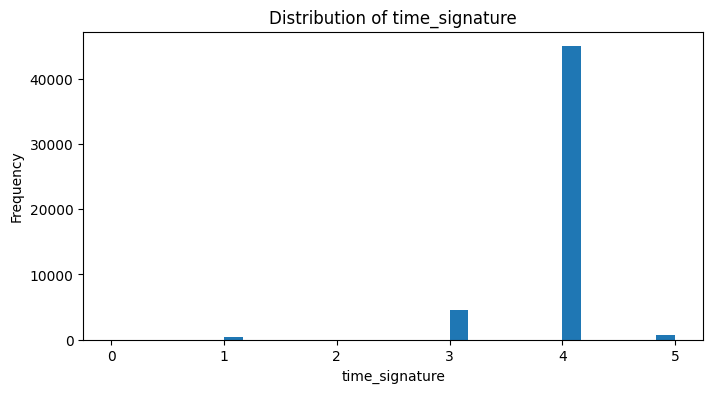

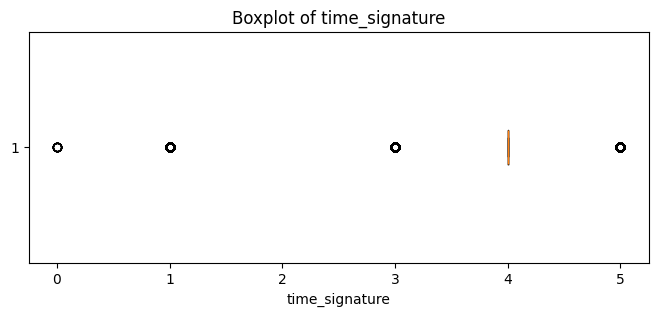

In [ ]:
numerical_analysis(df_songs, "time_signature")

In [ ]:
 import matplotlib.pyplot as plt
import seaborn as sns

def numerical_analysis(df):

    # select numerical columns
    num_df = df.select_dtypes(include="number")

    # statistics
    display(
        num_df.describe().T
        .assign(
            missing_values=num_df.isna().sum(),
            unique_values=num_df.nunique(),
            skewness=num_df.skew(),
            kurtosis=num_df.kurt()
        )
    )

    # correlation heatmap
    plt.figure(figsize=(10,6))
    sns.heatmap(
        num_df.corr(),
        annot=True,
        cmap="coolwarm"
    )
    plt.title("Correlation Heatmap")
    plt.show()


    # pair plot
    sns.pairplot(
        num_df,
        diag_kind="kde"
    )

    plt.show()

,count,mean,std,min,25%,50%,75%,max,missing_values,unique_values,skewness,kurtosis
year,50674.0,2004.017109,8.860497,1900.0,2001.0,2006.0,2009.00,2022.0,0,75,-1.986817,7.349585
duration_ms,50674.0,251153.558807,107589.235090,1439.0,192733.0,234933.0,288182.75,3816373.0,0,24202,3.908298,55.101449
key,50674.0,5.312507,3.567967,0.0,2.0,5.0,9.00,11.0,0,12,-0.006326,-1.302483
mode,50674.0,0.631073,0.482519,0.0,0.0,1.0,1.00,1.0,0,2,-0.543309,-1.704883
time_signature,50674.0,3.898153,0.419686,0.0,4.0,4.0,4.00,5.0,0,5,-3.685393,21.262420


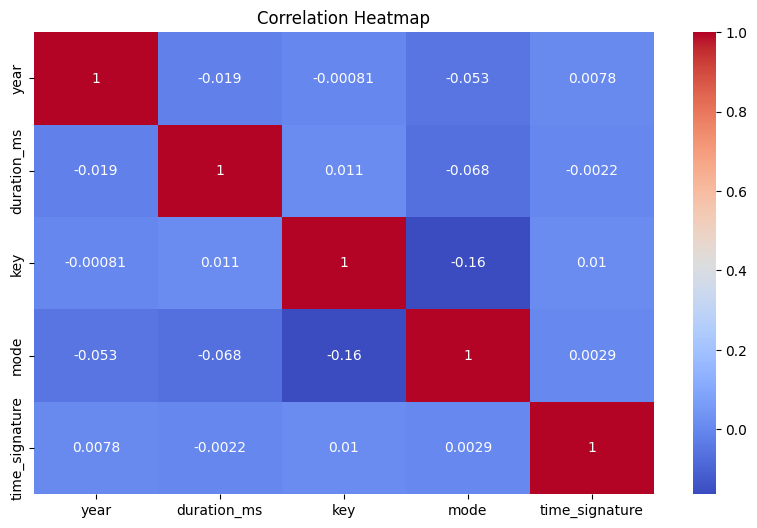

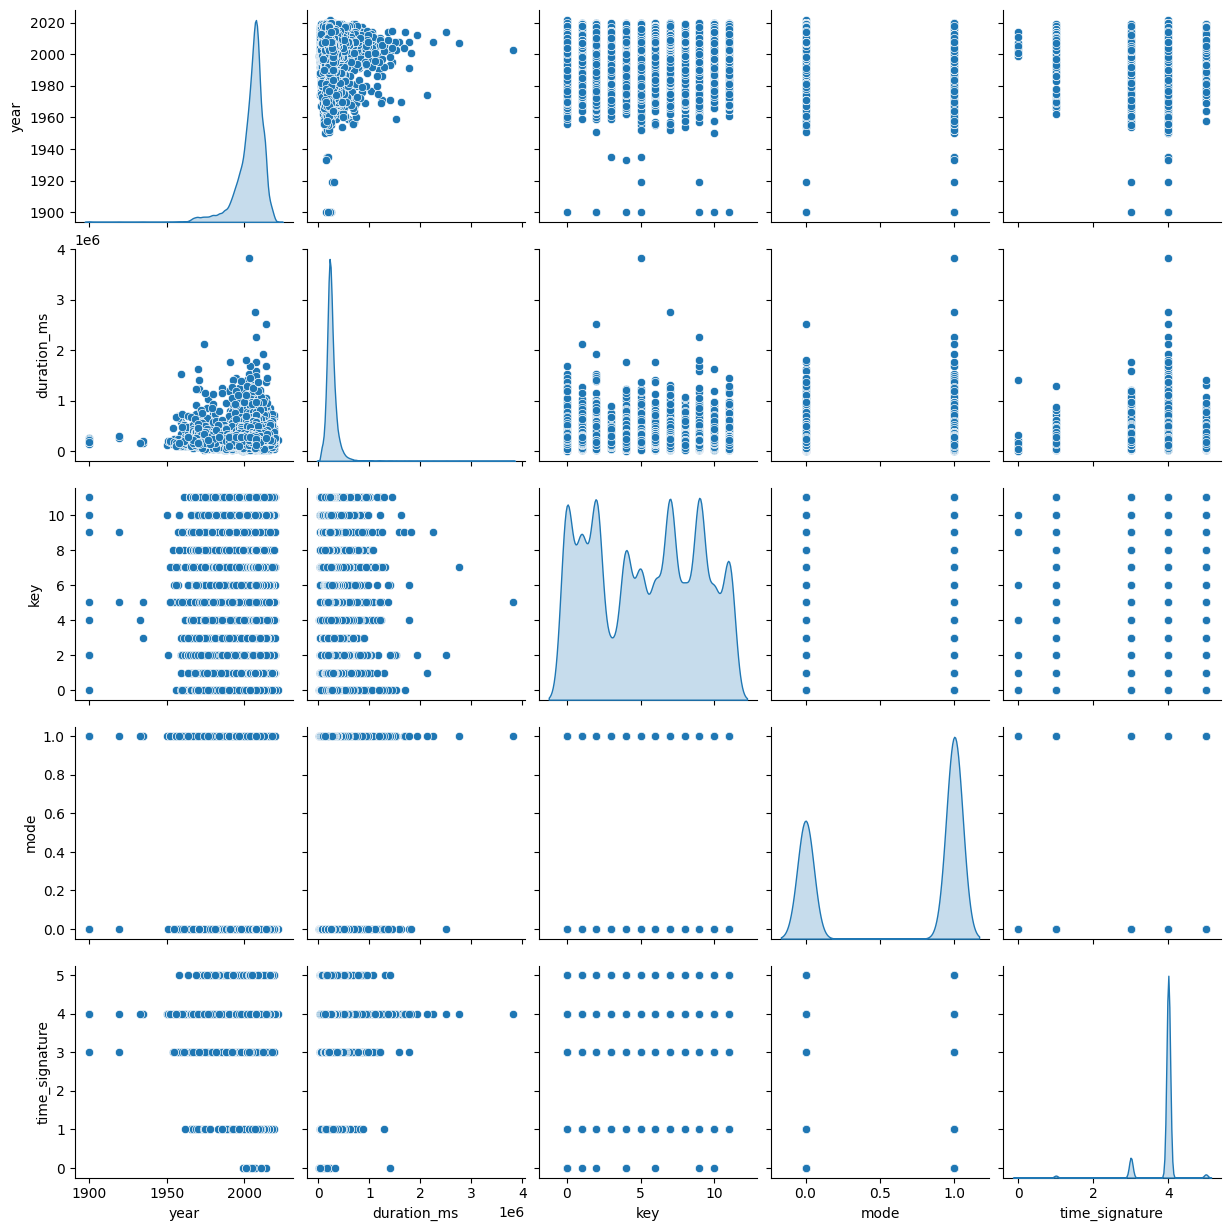

In [68]:
numerical_analysis(df_songs[integer_columns])

In [69]:
df_users = pd.read_csv(user_data_path)

In [70]:
df_users.head()

,track_id,user_id,playcount
0,TRIRLYL128F42539D1,b80344d063b5ccb3212f76538f3d9e43d87dca9e,1
1,TRFUPBA128F934F7E1,b80344d063b5ccb3212f76538f3d9e43d87dca9e,1
2,TRLQPQJ128F42AA94F,b80344d063b5ccb3212f76538f3d9e43d87dca9e,1
3,TRTUCUY128F92E1D24,b80344d063b5ccb3212f76538f3d9e43d87dca9e,1
4,TRHDDQG12903CB53EE,b80344d063b5ccb3212f76538f3d9e43d87dca9e,1


In [71]:
df_users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9711301 entries, 0 to 9711300
Data columns (total 3 columns):
 #   Column     Dtype 
---  ------     ----- 
 0   track_id   object
 1   user_id    object
 2   playcount  int64 
dtypes: int64(1), object(2)
memory usage: 222.3+ MB


In [72]:
df_users.describe()

,playcount
count,9.711301e+06
mean,2.630946e+00
std,5.706324e+00
min,1.000000e+00
25%,1.000000e+00
50%,1.000000e+00
75%,2.000000e+00
max,2.948000e+03


In [73]:
df_users.columns

Index(['track_id', 'user_id', 'playcount'], dtype='object')

In [74]:
df_users.duplicated(subset=['track_id','user_id']).sum()

np.int64(0)

In [75]:
df_users["user_id"].nunique()

962037

In [76]:
df_users["track_id"].nunique()

30459

In [77]:
df_users.loc[:,"track_id"].value_counts().head(10)

,count
track_id,
TRONYHY128F92C9D11,80656
TRUFTBY128F93450B8,39529
TRXWAZC128F9314B3E,30873
TRCPXID128F92D5D3C,30057
TRGCHLH12903CB7352,29708
TROMKCG128F9320C09,28735
TRPFYYL128F92F7144,28412
TRPGPDK12903CCC651,27276
TRWAQOC12903CB84CA,27222
